In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"

train_path = DATA_DIR / "train.csv"
test_path = DATA_DIR / "test.csv"

In [3]:
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (1460, 81)
Test shape: (1459, 80)


In [4]:
#Hedef değişkeni ayır
target = "SalePrice"
id_column = "Id"

y = train[target]
train_id = train[id_column]
test_id = test[id_column]

In [5]:
train_features = train.drop(columns=[target])
all_data = pd.concat([train_features, test], axis=0).reset_index(drop=True)

print("All data shape:", all_data.shape)

All data shape: (2919, 80)


In [6]:
missing_count = all_data.isnull().sum()
missing_percent = (missing_count / len(all_data)) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent
})

missing_summary = missing_summary[missing_summary["missing_count"] > 0]
missing_summary = missing_summary.sort_values(by="missing_percent", ascending=False)

missing_summary

,missing_count,missing_percent
PoolQC,2909,99.657417
MiscFeature,2814,96.402878
Alley,2721,93.216855
Fence,2348,80.438506
MasVnrType,1766,60.500171
FireplaceQu,1420,48.646797
LotFrontage,486,16.649538
GarageFinish,159,5.447071
GarageQual,159,5.447071
GarageCond,159,5.447071


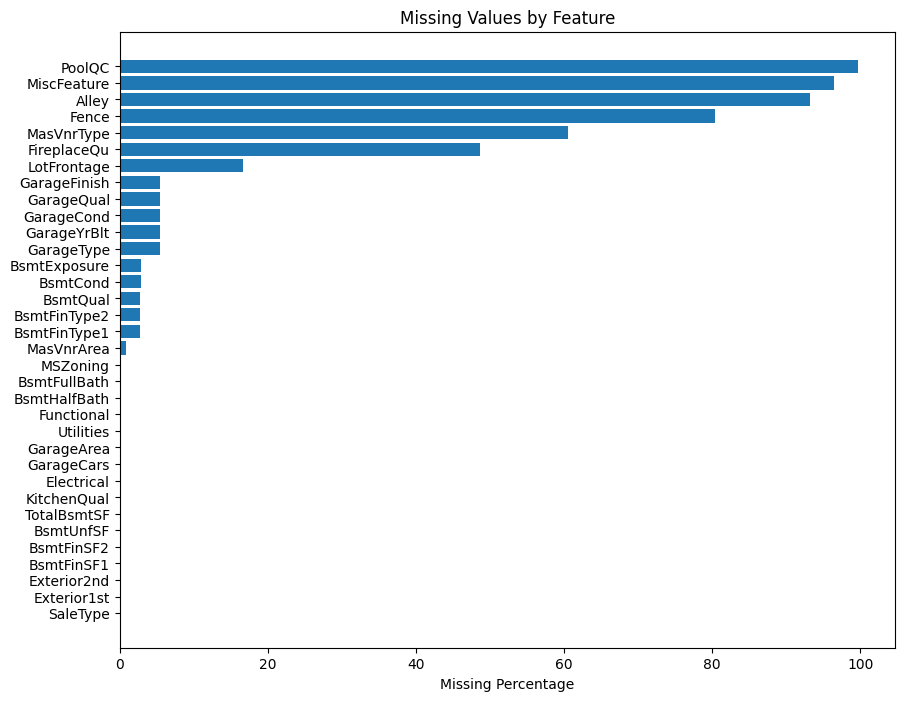

In [7]:
plt.figure(figsize=(10, 8))
plt.barh(missing_summary.index[::-1], missing_summary["missing_percent"].values[::-1])
plt.xlabel("Missing Percentage")
plt.title("Missing Values by Feature")
plt.show()

In [8]:
none_features = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "MasVnrType"
]

for col in none_features:
    all_data[col] = all_data[col].fillna("None")

In [9]:
zero_features = [
    "GarageYrBlt",
    "GarageArea",
    "GarageCars",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFullBath",
    "BsmtHalfBath",
    "MasVnrArea"
]

for col in zero_features:
    all_data[col] = all_data[col].fillna(0)

In [11]:
#LotFrontage için mahalle medyanı kullan
all_data["LotFrontage"] = all_data.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

In [12]:
#Eksik değerleri mode ile doldur
categorical_features = all_data.select_dtypes(include=["object"]).columns

for col in categorical_features:
    if all_data[col].isnull().sum() > 0:
        all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

In [13]:
#Kalan sayısal eksikleri medyan ile doldur
numeric_features = all_data.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_features:
    if all_data[col].isnull().sum() > 0:
        all_data[col] = all_data[col].fillna(all_data[col].median())

In [14]:
remaining_missing = all_data.isnull().sum().sum()

print("Remaining missing values:", remaining_missing)

Remaining missing values: 0


## Eksik Değerler Özet

Eksik değerler, kolonların anlamlarına göre ele alınmıştır.

- `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`, garaj ve bodrum ile ilgili kategorik değişkenlerdeki eksik değerler `"None"` olarak doldurulmuştur.
- Garaj, bodrum ve kaplama alanı gibi sayısal değişkenlerde eksik değerler `0` ile doldurulmuştur.
- `LotFrontage` değişkenindeki eksik değerler, `Neighborhood` bazlı medyan değerler kullanılarak doldurulmuştur.
- Kalan kategorik değişkenlerdeki eksik değerler en sık görülen değer ile doldurulmuştur.
- Kalan sayısal değişkenlerdeki eksik değerler medyan değer ile doldurulmuştur.
- Temizlik sonrası veri setinde eksik değer kalmamıştır.

## Missing Value Handling Summary

Missing values were handled based on the meaning of each feature.

- Missing values in categorical features such as `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`, and garage/basement-related features were filled with `"None"`.
- Missing values in numerical features related to garage, basement, and masonry veneer area were filled with `0`.
- Missing values in `LotFrontage` were filled using the median value within each `Neighborhood`.
- Remaining missing values in categorical features were filled with the most frequent value.
- Remaining missing values in numerical features were filled with the median value.
- After the cleaning process, there were no missing values left in the dataset.

### Feature Engineering

In [34]:
all_data["TotalSF"] = (
    all_data["TotalBsmtSF"] +
    all_data["1stFlrSF"] +
    all_data["2ndFlrSF"]
)

all_data["TotalBathrooms"] = (
    all_data["FullBath"] +
    0.5 * all_data["HalfBath"] +
    all_data["BsmtFullBath"] +
    0.5 * all_data["BsmtHalfBath"]
)

all_data["TotalPorchSF"] = (
    all_data["OpenPorchSF"] +
    all_data["EnclosedPorch"] +
    all_data["3SsnPorch"] +
    all_data["ScreenPorch"]
)

all_data["HouseAge"] = all_data["YrSold"] - all_data["YearBuilt"]
all_data["RemodAge"] = all_data["YrSold"] - all_data["YearRemodAdd"]

all_data["GarageAge"] = np.where(
    all_data["GarageYrBlt"] > 0,
    all_data["YrSold"] - all_data["GarageYrBlt"],
    0
)

In [35]:
all_data["HasGarage"] = (all_data["GarageArea"] > 0).astype(int)
all_data["HasBasement"] = (all_data["TotalBsmtSF"] > 0).astype(int)
all_data["HasFireplace"] = (all_data["Fireplaces"] > 0).astype(int)
all_data["HasPool"] = (all_data["PoolArea"] > 0).astype(int)
all_data["HasPorch"] = (all_data["TotalPorchSF"] > 0).astype(int)

In [36]:
new_features = [
    "TotalSF",
    "TotalBathrooms",
    "TotalPorchSF",
    "HouseAge",
    "RemodAge",
    "GarageAge",
    "HasGarage",
    "HasBasement",
    "HasFireplace",
    "HasPool",
    "HasPorch"
]

all_data[new_features].head()

,TotalSF,TotalBathrooms,TotalPorchSF,HouseAge,RemodAge,GarageAge,HasGarage,HasBasement,HasFireplace,HasPool,HasPorch
0,2566.0,3.5,61,5,5,5.0,1,1,0,0,1
1,2524.0,2.5,0,31,31,31.0,1,1,1,0,0
2,2706.0,3.5,42,7,6,7.0,1,1,1,0,1
3,2473.0,2.0,307,91,36,8.0,1,1,1,0,1
4,3343.0,3.5,84,8,8,8.0,1,1,1,0,1


In [37]:
age_features = ["HouseAge", "RemodAge", "GarageAge"]

for col in age_features:
    print(col)
    print("Min:", all_data[col].min())
    print("Max:", all_data[col].max())
    print()

HouseAge
Min: -1
Max: 136

RemodAge
Min: -2
Max: 60

GarageAge
Min: 0.0
Max: 114.0



In [38]:
invalid_age_rows = all_data[
    (all_data["HouseAge"] < 0) |
    (all_data["RemodAge"] < 0) |
    (all_data["GarageAge"] < 0)
]

invalid_age_rows[
    [
        "Id",
        "YearBuilt",
        "YearRemodAdd",
        "GarageYrBlt",
        "YrSold",
        "HouseAge",
        "RemodAge",
        "GarageAge"
    ]
]

,Id,YearBuilt,YearRemodAdd,GarageYrBlt,YrSold,HouseAge,RemodAge,GarageAge
523,524,2007,2008,2007.0,2007,0,-1,0.0
2295,2296,2007,2008,2007.0,2007,0,-1,0.0
2549,2550,2008,2009,2007.0,2007,-1,-2,0.0


In [39]:
invalid_yearbuilt = all_data["YearBuilt"] > all_data["YrSold"]
invalid_remod = all_data["YearRemodAdd"] > all_data["YrSold"]
invalid_garage = all_data["GarageYrBlt"] > all_data["YrSold"]

print("Invalid YearBuilt rows:", invalid_yearbuilt.sum())
print("Invalid YearRemodAdd rows:", invalid_remod.sum())
print("Invalid GarageYrBlt rows:", invalid_garage.sum())

all_data.loc[invalid_yearbuilt, "YearBuilt"] = all_data.loc[invalid_yearbuilt, "YrSold"]
all_data.loc[invalid_remod, "YearRemodAdd"] = all_data.loc[invalid_remod, "YrSold"]
all_data.loc[invalid_garage, "GarageYrBlt"] = all_data.loc[invalid_garage, "YrSold"]

Invalid YearBuilt rows: 1
Invalid YearRemodAdd rows: 3
Invalid GarageYrBlt rows: 0


In [40]:
all_data["HouseAge"] = all_data["YrSold"] - all_data["YearBuilt"]
all_data["RemodAge"] = all_data["YrSold"] - all_data["YearRemodAdd"]

all_data["GarageAge"] = np.where(
    all_data["GarageYrBlt"] > 0,
    all_data["YrSold"] - all_data["GarageYrBlt"],
    0
)

In [41]:
for col in age_features:
    print(col)
    print("Min:", all_data[col].min())
    print("Max:", all_data[col].max())
    print()

HouseAge
Min: 0
Max: 136

RemodAge
Min: 0
Max: 60

GarageAge
Min: 0.0
Max: 114.0



In [42]:
all_data[all_data["Id"].isin([524, 2296, 2550, 2593])][
    [
        "Id",
        "YearBuilt",
        "YearRemodAdd",
        "GarageYrBlt",
        "YrSold",
        "HouseAge",
        "RemodAge",
        "GarageAge"
    ]
]

,Id,YearBuilt,YearRemodAdd,GarageYrBlt,YrSold,HouseAge,RemodAge,GarageAge
523,524,2007,2007,2007.0,2007,0,0,0.0
2295,2296,2007,2007,2007.0,2007,0,0,0.0
2549,2550,2007,2007,2007.0,2007,0,0,0.0
2592,2593,2006,2007,2007.0,2007,1,0,0.0


In [43]:
print("All data shape after feature engineering:", all_data.shape)

All data shape after feature engineering: (2919, 91)


In [44]:
train_cleaned = all_data.iloc[:len(train), :].copy()
test_cleaned = all_data.iloc[len(train):, :].copy()

print("Train cleaned shape:", train_cleaned.shape)
print("Test cleaned shape:", test_cleaned.shape)

Train cleaned shape: (1460, 91)
Test cleaned shape: (1459, 91)


In [45]:
y_log = np.log1p(y)

print("Original target shape:", y.shape)
print("Log target shape:", y_log.shape)

Original target shape: (1460,)
Log target shape: (1460,)


In [46]:
print("Train cleaned missing values:", train_cleaned.isnull().sum().sum())
print("Test cleaned missing values:", test_cleaned.isnull().sum().sum())
print("Target missing values:", y.isnull().sum())
print("Log target missing values:", y_log.isnull().sum())

Train cleaned missing values: 0
Test cleaned missing values: 0
Target missing values: 0
Log target missing values: 0


## Missing Value Handling and Feature Engineering Summary

Eksik değerler, kolonların anlamlarına göre ele alınmıştır.

- `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`, garaj ve bodrum ile ilgili kategorik değişkenlerdeki eksik değerler `"None"` olarak doldurulmuştur.
- Garaj, bodrum ve kaplama alanı gibi sayısal değişkenlerde eksik değerler `0` ile doldurulmuştur.
- `LotFrontage` değişkenindeki eksik değerler, `Neighborhood` bazlı medyan değerler kullanılarak doldurulmuştur.
- Kalan kategorik değişkenlerdeki eksik değerler en sık görülen değer ile doldurulmuştur.
- Kalan sayısal değişkenlerdeki eksik değerler medyan değer ile doldurulmuştur.
- Temizlik sonrası veri setinde eksik değer kalmamıştır.
- `TotalSF`, `TotalBathrooms`, `TotalPorchSF`, `HouseAge`, `RemodAge`, `GarageAge` gibi yeni değişkenler oluşturulmuştur.
- `HasGarage`, `HasBasement`, `HasFireplace`, `HasPool`, `HasPorch` gibi ikili değişkenler eklenmiştir.
- Tarih bazlı değişkenlerdeki mantıksız negatif yaş değerleri kontrol edilmiş ve düzeltilmiştir.

## Missing Value Handling and Feature Engineering Summary

Missing values were handled based on the meaning of each feature.

- Missing values in categorical features such as `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`, and garage/basement-related features were filled with `"None"`.
- Missing values in numerical features related to garage, basement, and masonry veneer area were filled with `0`.
- Missing values in `LotFrontage` were filled using the median value within each `Neighborhood`.
- Remaining missing values in categorical features were filled with the most frequent value.
- Remaining missing values in numerical features were filled with the median value.
- After the cleaning process, there were no missing values left in the dataset.
- New features such as `TotalSF`, `TotalBathrooms`, `TotalPorchSF`, `HouseAge`, `RemodAge`, and `GarageAge` were created.
- Binary indicator features such as `HasGarage`, `HasBasement`, `HasFireplace`, `HasPool`, and `HasPorch` were added.
- Inconsistent date-based features causing negative age values were detected and corrected.

In [47]:
PROCESSED_DIR = BASE_DIR / "outputs" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

train_cleaned.to_csv(PROCESSED_DIR / "train_cleaned.csv", index=False)
test_cleaned.to_csv(PROCESSED_DIR / "test_cleaned.csv", index=False)

pd.DataFrame({"SalePrice": y, "SalePrice_Log": y_log}).to_csv(
    PROCESSED_DIR / "target.csv",
    index=False
)

print("Processed files saved successfully.")

Processed files saved successfully.
